【Data Scaling(데이터 스케일링)】
- 서로 다른 변수의 값 범위를 일정한 수준으로 맞추는 작업을 피처 스케일링(feature scaling)이라고 한다.
- 피처(feature)=컬럼(column) 들마다 데이터의 값이 범위가 다 제각각이거나 단위가 다른 경우 데이터를 학습을 할때 0으로 수렴하거나 무한으로 발산할 수 있다.
  - 분석시에 변수들이 너무 스케일이 다를 경우  => 변수들의 단위 차이로 인해 숫자의 스케일이 크게 달라지는 경우
  - 신경망 학습시에 => 데이터셋의 값이 들쑥날쑥하거나, 매우 큰 경우에는 cost의 값이 발산하여 정상적인 학습이 이루어지지 않습니다.

- 이런 경우 데이터 스켈링을 통해 모든 피처들의 데이터 분포나 범위를 동일하게 조정해 줄 수 있다.
- Scaling 메서드는 scikit-learn의 preprocessing에서 제공한다.
- sklearn에서 제공하는 기본 Scaling 종류
   - StandardScaler : 평균이 0 분산이 1인 정규분포로 변환
   - MinMaxScaler :  0 ~ 1 사이의 실수로 변환, 타이타닉 생존자 예측(0 또는 1)과 같은 분류 문제보다는, 아파트 실거래가격 예측과 같은 회귀 문제를 해결할 때 더 적합한 스케일링 기법
   - RobustScaler : 중앙값이 0, 중앙값을 0으로, IQR을 1로 변환, StandardScaler에 비해 이상치의 영향이 적어진다는 장점
   - MaxAbsScaler : 모든 피처들의 절댓값이 0과 1 사이에 놓이도록 변환, 극단적인 이상치에는 민감할 수 있으므로 꼭 이상치를 제거
   - Normalizer :  row를 기준으로 row(data point)마다 정규화를 진행, 한 행의 모든 features 사이에 유클리드 거리가 1이 되도록 데이터값을 변환, Normalizer를 사용하면 학습 속도도 빨라지고 과대적합 확률을 낮춤

In [48]:
# '파이썬 라이브러리를 활용한 머신러닝'의 저자가 제공한 라이브러리
# !uv add mglearn

In [49]:
import mglearn

In [50]:
print(dir(mglearn))

['ReBl', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'cm2', 'cm3', 'datasets', 'discrete_scatter', 'plot_2d_separator', 'plot_agglomerative', 'plot_animal_tree', 'plot_cross_validation', 'plot_dbscan', 'plot_decomposition', 'plot_grid_search', 'plot_helpers', 'plot_improper_preprocessing', 'plot_interactive_tree', 'plot_kmeans', 'plot_kneighbors_regularization', 'plot_knn_classification', 'plot_knn_regression', 'plot_linear_regression', 'plot_linear_svc_regularization', 'plot_metrics', 'plot_nmf', 'plot_nn_graphs', 'plot_pca', 'plot_rbf_svm_parameters', 'plot_ridge', 'plot_scaling', 'plot_tree_nonmonotonous', 'plots', 'tools']


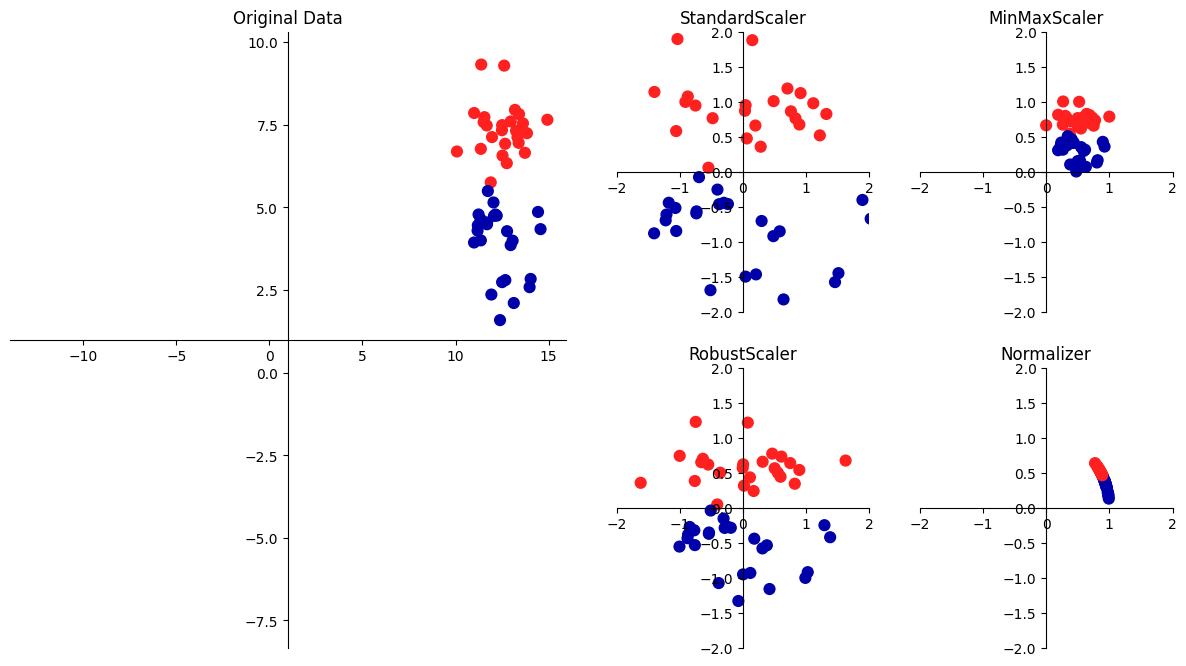

In [51]:
mglearn.plot_scaling.plot_scaling()

1. ## **`MaxAbsScaler`**

- 데이터의 **절대값이 1을 넘지 않도록** 스케일링
- 음수와 양수 값이 섞인 sparse 데이터에 적합
- 이상치에 민감하며, 분류보다는 회귀분석에서 유용


In [52]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()
X_scaled = scaler.fit_transform([[-1, 23], [0, 3], [1, -2]])
X_scaled


array([[-1.        ,  1.        ],
       [ 0.        ,  0.13043478],
       [ 1.        , -0.08695652]])

2. MinMaxScaler

- **최소-최대 정규화**: 데이터를 `[0, 1]` 범위로 변환
- 정규분포가 아닐때 사용
- 이상치에 민감
- 분류보다 회귀에 유용

In [53]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform([[1, 2], [3, 4], [5, 6]])
X_scaled


array([[0. , 0. ],
       [0.5, 0.5],
       [1. , 1. ]])

2.3 StandardScaler

- **Z-score 정규화**: 평균을 0, 표준편차를 1로 변환
- 이상치 영향을 받으므로 이상치가 없을때 사용
- 회귀보다는 분류분석에서 유용

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform([[1, 2], [3, 4], [5, 6]])
X_scaled


array([[-1.22474487, -1.22474487],
       [ 0.        ,  0.        ],
       [ 1.22474487,  1.22474487]])

2.4 Normalizer
- 각 행의 벡터 크기를 1로 정규화 (L1, L2, Max 노름 사용 가능)

In [55]:
from sklearn.preprocessing import Normalizer

normalizer = Normalizer(norm='l2')
X_normalized = normalizer.transform([[1, 2], [3, 4]])
X_normalized


array([[0.4472136 , 0.89442719],
       [0.6       , 0.8       ]])

2.5 RobustScaler
- **중앙값과 IQR(사분위 범위) 기반 정규화**
- 이상치(Outlier)에 강한 정규화 방법

In [56]:
from sklearn.preprocessing import RobustScaler
import pandas as pd

# 예제 데이터
data = {
    'Income': [3000, 3200, 3400, 100000, 3600],  # 이상치 존재
    'Age': [25, 26, 27, 28, 29]
}
df = pd.DataFrame(data)
print(" 원본 데이터:\n", df)

# RobustScaler 객체 생성 및 적용
scaler = RobustScaler()
scaled_data = scaler.fit_transform(df)

# 결과를 DataFrame으로 변환
df_scaled = pd.DataFrame(scaled_data, columns=['Income_scaled', 'Age_scaled'])
print("RobustScaler 결과:\n", df_scaled)

# 3          241.5         0.5  이상이 영향 작음

 원본 데이터:
    Income  Age
0    3000   25
1    3200   26
2    3400   27
3  100000   28
4    3600   29
RobustScaler 결과:
    Income_scaled  Age_scaled
0           -1.0        -1.0
1           -0.5        -0.5
2            0.0         0.0
3          241.5         0.5
4            0.5         1.0


| Feature 이름          | 설명      | 단위 |
| ------------------- | ------- | -- |
| `sepal length (cm)` | 꽃받침의 길이 | cm |
| `sepal width (cm)`  | 꽃받침의 너비 | cm |
| `petal length (cm)` | 꽃잎의 길이  | cm |
| `petal width (cm)`  | 꽃잎의 너비  | cm |


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import MaxAbsScaler
from sklearn.preprocessing import RobustScaler

In [58]:
iris = load_iris()
print(dir(iris))
print(iris.target)

iris = pd.DataFrame(iris.data, columns=iris.feature_names)

iris['Class'] = load_iris().target
iris['Class'] = iris['Class'].map({0:'Setosa', 1:'Versicolour', 2:'Virginica'})
iris.head()

['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Class
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [ ]:
from sklearn.model_selection import train_test_split


#X_관측값_훈련,X_관측값_테스트,y_정답_훈련,y_정답_테스트
# stratify=iris['Class'] : train, test을 분리할 때 값의 비율을 유지하면서 분리하도록 설정한 파라미터이다.
# stratify을 설정
X_train, X_test, y_train, y_test = train_test_split(iris.drop(columns='Class'), iris['Class'],   test_size=0.2) #  test_size=0.25.


In [60]:
X_train.head(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
122,7.7,2.8,6.7,2.0
108,6.7,2.5,5.8,1.8
110,6.5,3.2,5.1,2.0
149,5.9,3.0,5.1,1.8
31,5.4,3.4,1.5,0.4


In [61]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(120, 4) (120,)
(30, 4) (30,)


In [62]:
print(y_train.value_counts())

Class
Setosa         41
Versicolour    40
Virginica      39
Name: count, dtype: int64


In [63]:
print(y_test.value_counts())

Class
Virginica      11
Versicolour    10
Setosa          9
Name: count, dtype: int64


In [64]:
import seaborn as sns

In [65]:
print(type(y_train))
print(y_train.head())

<class 'pandas.core.series.Series'>
122    Virginica
108    Virginica
110    Virginica
149    Virginica
31        Setosa
Name: Class, dtype: object


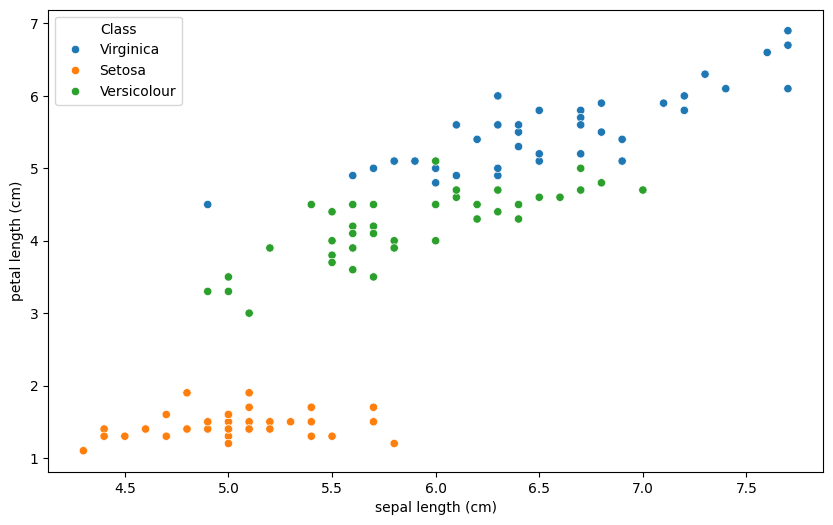

In [66]:
fig =sns.scatterplot(data=X_train, x=X_train.iloc[:,0], y=X_train.iloc[:,2], hue=y_train)
fig.figure.set_size_inches(10,6)

In [ ]:
StdScaler = StandardScaler()

# Train데이터의 fitting과 스케일링
StdScaler.fit(X_train) # fit()은 학습을 시키는 메소드이다.
X_train_sc = StdScaler.transform(X_train) # transform() 실제로 학습시킨 것을 적용하는 메소드이다.

print('\t\t(min, max)  (mean,std)')
print('Train_scaled (%.2f, %.2f) ( %.2f, %.2f)'%(X_train_sc.min(), X_train_sc.max(), X_train_sc.mean(),X_train_sc.std()))

		(min, max)  (mean,std)
Train_scaled (-2.38, 3.17) ( -0.00, 1.00)


In [68]:
StdScaler2 = StandardScaler()
StdScaler2.fit_transform(X_train)

array([[ 2.37102852e+00, -5.29615478e-01,  1.71970605e+00,
         1.07828856e+00],
       [ 1.12257120e+00, -1.22293028e+00,  1.20393750e+00,
         8.13677873e-01],
       [ 8.72879739e-01,  3.94804265e-01,  8.02784191e-01,
         1.07828856e+00],
       [ 1.23805350e-01, -6.74056063e-02,  8.02784191e-01,
         8.13677873e-01],
       [-5.00423307e-01,  8.57014137e-01, -1.26028999e+00,
        -1.03859696e+00],
       [-1.25886113e-01, -2.98510542e-01,  2.87015645e-01,
         1.52151147e-01],
       [-1.37434343e+00,  3.94804265e-01, -1.20298238e+00,
        -1.30320765e+00],
       [-8.74960501e-01,  8.57014137e-01, -1.26028999e+00,
        -1.30320765e+00],
       [ 1.12257120e+00,  6.25909201e-01,  1.14662989e+00,
         1.73981529e+00],
       [ 1.24741693e+00,  3.94804265e-01,  1.26124512e+00,
         1.47520460e+00],
       [-3.75577576e-01, -1.68514016e+00,  1.72400412e-01,
         1.52151147e-01],
       [-1.12465196e+00,  1.63699329e-01, -1.26028999e+00,
      

In [69]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,2.371029,1.122571,0.872880,0.123805,-0.500423,-0.125886,-1.374343,-0.874961,1.122571,1.247417,...,-0.750115,-0.874961,-0.250732,-0.750115,0.748034,-1.124652,-0.125886,1.247417,0.623188,-0.874961
1,-0.529615,-1.222930,0.394804,-0.067406,0.857014,-0.298511,0.394804,0.857014,0.625909,0.394804,...,0.857014,1.088119,-0.067406,-0.760720,-0.529615,0.163699,-0.529615,-0.529615,0.625909,0.625909
2,1.719706,1.203938,0.802784,0.802784,-1.260290,0.287016,-1.202982,-1.260290,1.146630,1.261245,...,-1.317598,-1.317598,0.458938,0.115093,1.089322,-1.260290,0.229708,0.630861,0.573554,-1.145675
3,1.078289,0.813678,1.078289,0.813678,-1.038597,0.152151,-1.303208,-1.303208,1.739815,1.475205,...,-1.303208,-1.303208,0.416762,0.284456,1.210594,-1.303208,0.152151,0.284456,0.549067,-0.906292


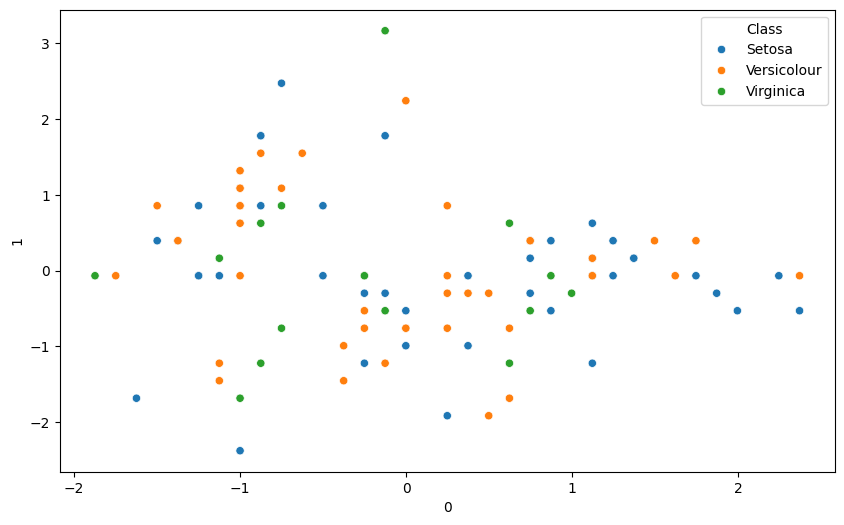

In [70]:
fig =sns.scatterplot(data=xt, x=xt.iloc[0,:], y=xt.iloc[1,], hue=y_train)
fig.figure.set_size_inches(10,6)

In [71]:
from sklearn.preprocessing import MinMaxScaler

MmScaler = MinMaxScaler()

# Train 데이터의 fitting과 스케일링
# fit()은 학습을 시키는 메소드이다.
MmScaler.fit(X_train)

#transform()은 실제로 학습시킨 것을 적용하는 메소드이다.
X_train_sc = MmScaler.transform(X_train)
print(X_train_sc.shape)

print('\t\t(min, max)  (mean,std)')
print('Train_scaled (%.2f, %.2f) ( %.2f, %.2f)'%(X_train_sc.min(), X_train_sc.max(), X_train_sc.mean(),X_train_sc.std()))

(120, 4)
		(min, max)  (mean,std)
Train_scaled (0.00, 1.00) ( 0.44, 0.26)


(480,)


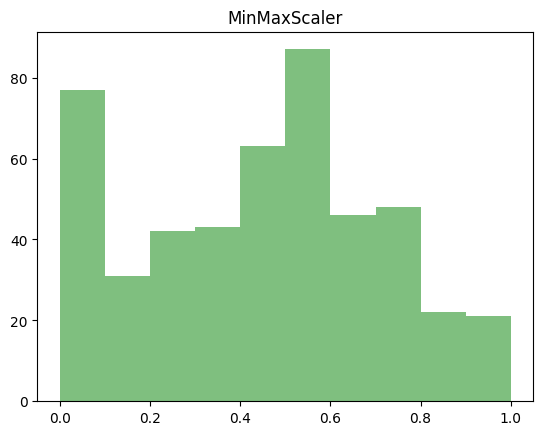

In [72]:
X_train_sc_flat = X_train_sc.flatten()
print(X_train_sc_flat.shape)
#print(X_train_sc_flat)
plt.hist(X_train_sc_flat, color='green', alpha=0.5)
plt.title('MinMaxScaler')
plt.show()

In [73]:
xt = pd.DataFrame(X_train_sc).T

In [74]:
xt.iloc[0, :].shape

(120,)

In [75]:
xt.iloc[1, :].shape

(120,)

In [76]:
xt.shape

(4, 120)

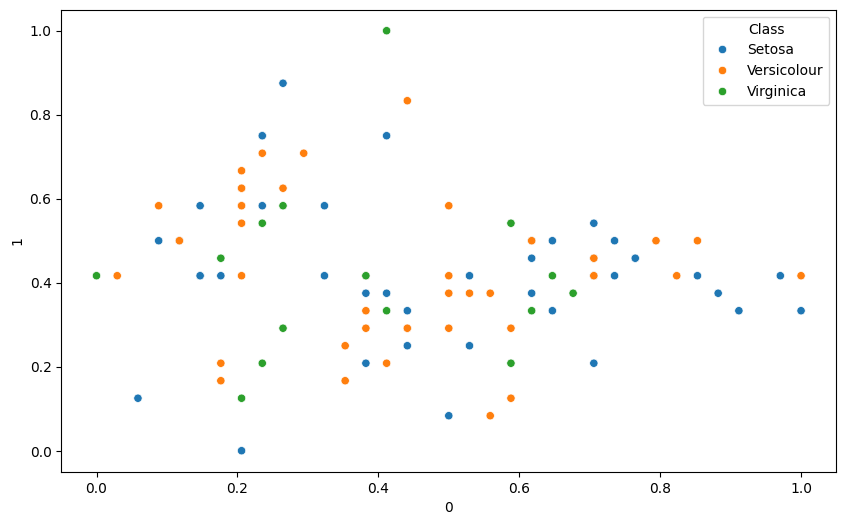

In [77]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [78]:
from sklearn.preprocessing import MaxAbsScaler

MaScaler = MaxAbsScaler()

# Train 데이터의 fitting과 스케일링
MaScaler.fit(X_train)
X_train_sc = MaScaler.transform(X_train)


print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))

		(min, max) (mean, std)
Train_scaled (0.04, 1.00) (0.61, 0.24)


In [79]:
X_train_sc.shape

(120, 4)

In [80]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,1.000000,0.870130,0.844156,0.766234,0.701299,0.740260,0.610390,0.662338,0.870130,0.883117,...,0.675325,0.662338,0.727273,0.675325,0.831169,0.636364,0.740260,0.883117,0.818182,0.662338
1,0.636364,0.568182,0.727273,0.681818,0.772727,0.659091,0.727273,0.772727,0.750000,0.727273,...,0.772727,0.795455,0.681818,0.613636,0.636364,0.704545,0.636364,0.636364,0.750000,0.750000
2,0.971014,0.840580,0.739130,0.739130,0.217391,0.608696,0.231884,0.217391,0.826087,0.855072,...,0.202899,0.202899,0.652174,0.565217,0.811594,0.217391,0.594203,0.695652,0.681159,0.246377
3,0.800000,0.720000,0.800000,0.720000,0.160000,0.520000,0.080000,0.080000,1.000000,0.920000,...,0.080000,0.080000,0.600000,0.560000,0.840000,0.080000,0.520000,0.560000,0.640000,0.200000


In [81]:
xt.shape

(4, 120)

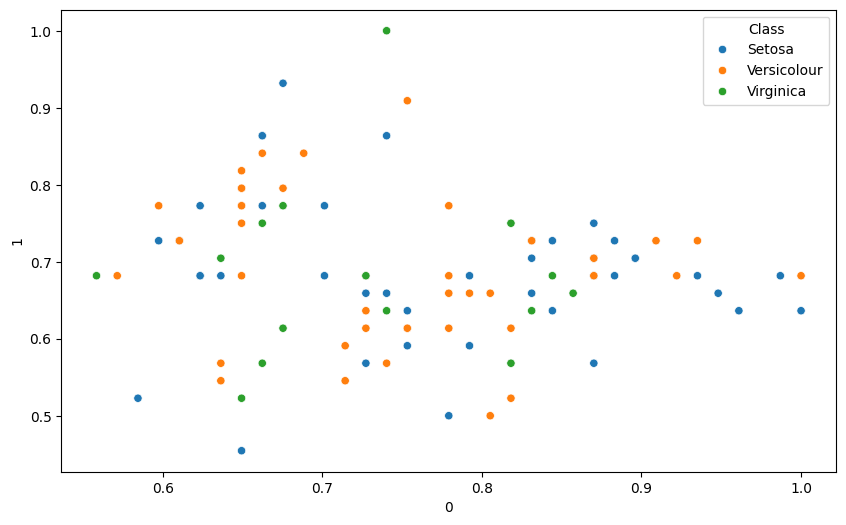

In [82]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [83]:
from sklearn.preprocessing import RobustScaler

RuScaler = RobustScaler()

# Train 데이터의 fitting과 스케일링
RuScaler.fit(X_train)
X_train_sc = RuScaler.transform(X_train)

print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))

		(min, max) (mean, std)
Train_scaled (-2.00, 2.80) (-0.02, 0.64)


In [84]:
xt = pd.DataFrame(X_train_sc.T)
xt

,0,1,2,3,4,5,6,7,8,9,...,110,111,112,113,114,115,116,117,118,119
0,1.538462,0.769231,0.615385,0.153846,-0.230769,0.000000,-0.769231,-0.461538,0.769231,0.846154,...,-0.384615,-0.461538,-0.076923,-0.384615,0.538462,-0.615385,0.000000,0.846154,0.461538,-0.461538
1,-0.400000,-1.000000,0.400000,0.000000,0.800000,-0.200000,0.400000,0.800000,0.600000,0.400000,...,0.800000,1.000000,0.000000,-0.600000,-0.400000,0.200000,-0.400000,-0.400000,0.600000,0.600000
2,0.680556,0.430556,0.236111,0.236111,-0.763889,-0.013889,-0.736111,-0.763889,0.402778,0.458333,...,-0.791667,-0.791667,0.069444,-0.097222,0.375000,-0.763889,-0.041667,0.152778,0.125000,-0.708333
3,0.466667,0.333333,0.466667,0.333333,-0.600000,0.000000,-0.733333,-0.733333,0.800000,0.666667,...,-0.733333,-0.733333,0.133333,0.066667,0.533333,-0.733333,0.000000,0.066667,0.200000,-0.533333


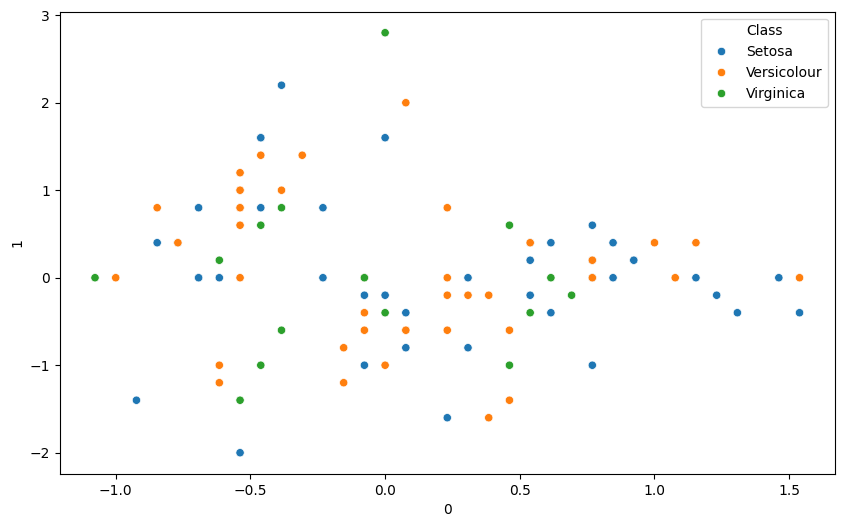

In [85]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)

In [86]:
from sklearn.preprocessing import Normalizer

NoScaler = Normalizer()


# Train 데이터의 fitting과 스케일링
NoScaler.fit(X_train)
X_train_sc = NoScaler.transform(X_train)


print("\t\t(min, max) (mean, std)")
print("Train_scaled (%.2f, %.2f) (%.2f, %.2f)"%(X_train_sc.min(), X_train_sc.max(),  X_train_sc.mean(),  X_train_sc.std()))


		(min, max) (mean, std)
Train_scaled (0.01, 0.86) (0.44, 0.24)


In [87]:
xt = pd.DataFrame(X_train_sc.T)

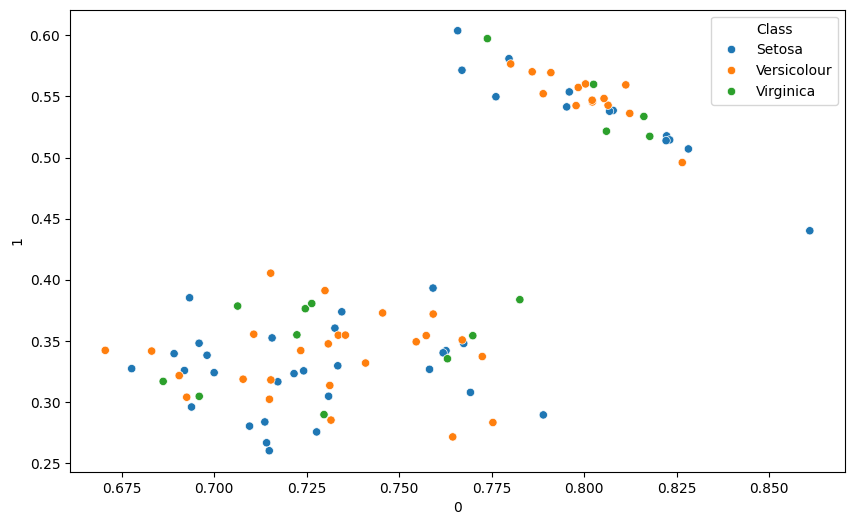

In [88]:
fig = sns.scatterplot(data=xt , x=xt.iloc[0,:], y=xt.iloc[1,:], hue=y_train)
fig.figure.set_size_inches(10,6)